# **Smart Machine Failure Prediction and Maintenance Alert System**

# Project objective

Develop and compare machine-learning classification models that estimate machine-failure risk using product type and operational sensor measurements.


* # Inputs
* Type
* Air temperature
* Process temperature
* Rotational speed
* Torque
* Tool wear
* # Output
* 0 = Normal operation
* 1 = Machine failure
* # Models
* Logistic Regression
* K-Nearest Neighbors
* Naive Bayes
* Decision Tree
* Random Forest
* Voting

# Importing Libraries

In [56]:
# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Data splitting and validation
from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_validate,
    GridSearchCV,
    RandomizedSearchCV
)

# Preprocessing
from sklearn.preprocessing import OneHotEncoder, StandardScaler, OrdinalEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Machine-learning models
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import BaggingClassifier, VotingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn import set_config
from IPython.display import display


# Model evaluation
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report
)



# reading the Dataset

In [57]:
df=pd.read_csv('ai4i2020.csv')

# EDA

In [58]:
df.head()

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


In [59]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 10000
Number of columns: 14


In [60]:
df.sample(5, random_state=42)

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
6252,6253,L53432,L,300.8,310.3,1538,36.1,198,0,0,0,0,0,0
4684,4685,M19544,M,303.6,311.8,1421,44.8,101,1,0,0,0,0,0
1731,1732,M16591,M,298.3,307.9,1485,42.0,117,0,0,0,0,0,0
4742,4743,L51922,L,303.3,311.3,1592,33.7,14,0,0,0,0,0,0
4521,4522,L51701,L,302.4,310.4,1865,23.9,129,0,0,0,0,0,0


In [61]:
print(df.columns.tolist())

['UDI', 'Product ID', 'Type', 'Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]', 'Machine failure', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF']


In [62]:
for column in df.columns:
    print(repr(column))

'UDI'
'Product ID'
'Type'
'Air temperature [K]'
'Process temperature [K]'
'Rotational speed [rpm]'
'Torque [Nm]'
'Tool wear [min]'
'Machine failure'
'TWF'
'HDF'
'PWF'
'OSF'
'RNF'


removing beginning or ending spaces

In [63]:
df.columns = df.columns.str.strip()

In [64]:
rename_columns = {
    "UDI": "udi",
    "Product ID": "product_id",
    "Type": "product_type",
    "Air temperature [K]": "air_temperature",
    "Process temperature [K]": "process_temperature",
    "Rotational speed [rpm]": "rotational_speed",
    "Torque [Nm]": "torque",
    "Tool wear [min]": "tool_wear",
    "Machine failure": "machine_failure",
    "TWF": "twf",
    "HDF": "hdf",
    "PWF": "pwf",
    "OSF": "osf",
    "RNF": "rnf"
}

df.rename(columns=rename_columns, inplace=True)

df.columns.tolist()

['udi',
 'product_id',
 'product_type',
 'air_temperature',
 'process_temperature',
 'rotational_speed',
 'torque',
 'tool_wear',
 'machine_failure',
 'twf',
 'hdf',
 'pwf',
 'osf',
 'rnf']

In [65]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   udi                  10000 non-null  int64  
 1   product_id           10000 non-null  str    
 2   product_type         10000 non-null  str    
 3   air_temperature      10000 non-null  float64
 4   process_temperature  10000 non-null  float64
 5   rotational_speed     10000 non-null  int64  
 6   torque               10000 non-null  float64
 7   tool_wear            10000 non-null  int64  
 8   machine_failure      10000 non-null  int64  
 9   twf                  10000 non-null  int64  
 10  hdf                  10000 non-null  int64  
 11  pwf                  10000 non-null  int64  
 12  osf                  10000 non-null  int64  
 13  rnf                  10000 non-null  int64  
dtypes: float64(3), int64(9), str(2)
memory usage: 1.1 MB


In [66]:
df.dtypes

udi                      int64
product_id                 str
product_type               str
air_temperature        float64
process_temperature    float64
rotational_speed         int64
torque                 float64
tool_wear                int64
machine_failure          int64
twf                      int64
hdf                      int64
pwf                      int64
osf                      int64
rnf                      int64
dtype: object

In [67]:
quality_report = pd.DataFrame({
    "Data Type": df.dtypes.astype(str),
    "Missing Values": df.isnull().sum(),
    "Missing Percentage": (
        df.isnull().sum() / len(df) * 100
    ).round(2),
    "Unique Values": df.nunique()
})

quality_report

,Data Type,Missing Values,Missing Percentage,Unique Values
udi,int64,0,0.0,10000
product_id,str,0,0.0,10000
product_type,str,0,0.0,3
air_temperature,float64,0,0.0,93
process_temperature,float64,0,0.0,82
rotational_speed,int64,0,0.0,941
torque,float64,0,0.0,577
tool_wear,int64,0,0.0,246
machine_failure,int64,0,0.0,2
twf,int64,0,0.0,2


This report shows:

* The type of every column
* Missing-value count
* Missing-value percentage
* Number of unique values

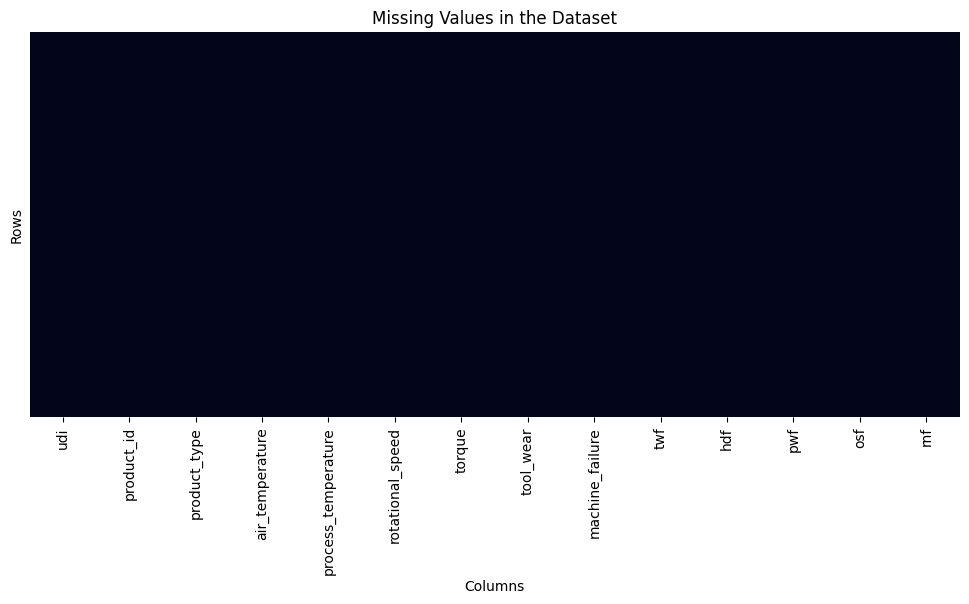

In [68]:
plt.figure(figsize=(12, 5))

sns.heatmap(
    df.isnull(),
    cbar=False,
    yticklabels=False
)

plt.title("Missing Values in the Dataset")
plt.xlabel("Columns")
plt.ylabel("Rows")
plt.show()

Even when the expected result is zero, this check must still be included in the project.

In [69]:
df.duplicated().sum()

np.int64(0)

In [70]:
df.columns

Index(['udi', 'product_id', 'product_type', 'air_temperature',
       'process_temperature', 'rotational_speed', 'torque', 'tool_wear',
       'machine_failure', 'twf', 'hdf', 'pwf', 'osf', 'rnf'],
      dtype='str')

In [71]:
print(df["product_type"].unique())

<ArrowStringArray>
['M', 'L', 'H']
Length: 3, dtype: str


In [72]:
binary_columns = [
    "machine_failure",
    "twf",
    "hdf",
    "pwf",
    "osf",
    "rnf"
]

for column in binary_columns:
    print(column, sorted(df[column].unique()))

machine_failure [np.int64(0), np.int64(1)]
twf [np.int64(0), np.int64(1)]
hdf [np.int64(0), np.int64(1)]
pwf [np.int64(0), np.int64(1)]
osf [np.int64(0), np.int64(1)]
rnf [np.int64(0), np.int64(1)]


making sure categorical columns contain 0s and 1s

In [73]:
numerical_features = [
    "air_temperature",
    "process_temperature",
    "rotational_speed",
    "torque",
    "tool_wear"
]

df[numerical_features].describe()

,air_temperature,process_temperature,rotational_speed,torque,tool_wear
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,300.004930,310.005560,1538.776100,39.986910,107.951000
std,2.000259,1.483734,179.284096,9.968934,63.654147
min,295.300000,305.700000,1168.000000,3.800000,0.000000
25%,298.300000,308.800000,1423.000000,33.200000,53.000000
50%,300.100000,310.100000,1503.000000,40.100000,108.000000
75%,301.500000,311.100000,1612.000000,46.800000,162.000000
max,304.500000,313.800000,2886.000000,76.600000,253.000000


In [74]:
range_checks = {
    "Negative air temperature": (df["air_temperature"] < 0).sum(),
    "Negative process temperature": (
        df["process_temperature"] < 0
    ).sum(),
    "Non-positive rotational speed": (
        df["rotational_speed"] <= 0
    ).sum(),
    "Negative torque": (df["torque"] < 0).sum(),
    "Negative tool wear": (df["tool_wear"] < 0).sum()
}

pd.Series(range_checks, name="Invalid Count")

Negative air temperature         0
Negative process temperature     0
Non-positive rotational speed    0
Negative torque                  0
Negative tool wear               0
Name: Invalid Count, dtype: int64

Checking impossible or suspicious values

In [75]:
invalid_rows = (
    df["process_temperature"] < df["air_temperature"]
).sum()

print(invalid_rows)

0


it means every process temperature is equal to or higher than the air temperature so no sus values

In [76]:
df['machine_failure'].value_counts()

machine_failure
0    9661
1     339
Name: count, dtype: int64

In [77]:
x="failure_label"

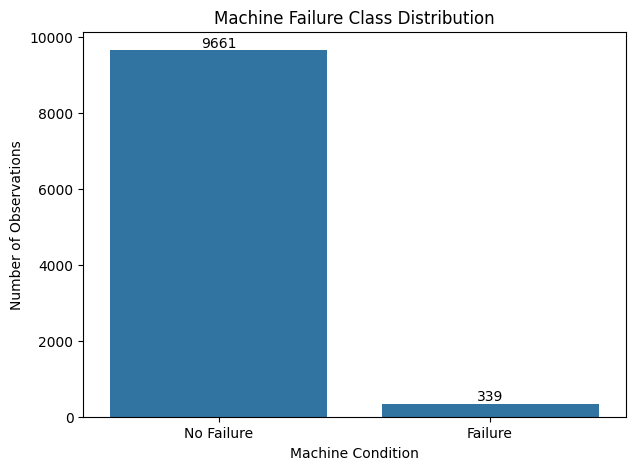

In [78]:
df["failure_label"] = df["machine_failure"].map({0: "No Failure", 1: "Failure"})

plt.figure(figsize=(7, 5))

ax = sns.countplot(
    data=df,
    x="failure_label",
    order=["No Failure", "Failure"]
)

for container in ax.containers:
    ax.bar_label(container)

plt.title("Machine Failure Class Distribution")
plt.xlabel("Machine Condition")
plt.ylabel("Number of Observations")
plt.show()

imbalanced target (so accuracy cannot be the only evaluation metric)

In [79]:
baseline_accuracy = (
    df["machine_failure"].value_counts().max()
    / len(df)
)

print(
    "Accuracy from always predicting no failure:",
    round(baseline_accuracy * 100, 2),
    "%"
)

Accuracy from always predicting no failure: 96.61 %


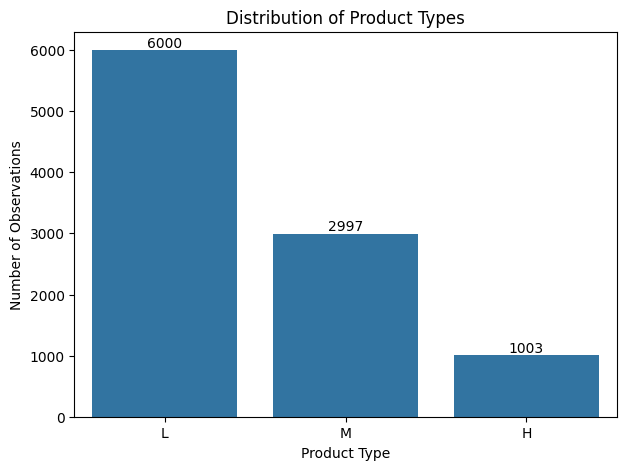

In [80]:
plt.figure(figsize=(7, 5))

ax = sns.countplot(
    data=df,
    x="product_type",
    order=["L", "M", "H"]
)

for container in ax.containers:
    ax.bar_label(container)

plt.title("Distribution of Product Types")
plt.xlabel("Product Type")
plt.ylabel("Number of Observations")
plt.show()

majority of the machines's types are low

In [81]:
type_failure_summary = (
    df.groupby("product_type")
    .agg(
        total_observations=("machine_failure", "size"),
        failure_count=("machine_failure", "sum"),
        failure_rate=("machine_failure", "mean")
    )
)

type_failure_summary["failure_rate_percentage"] = (
    type_failure_summary["failure_rate"] * 100
).round(2)

type_failure_summary

,total_observations,failure_count,failure_rate,failure_rate_percentage
product_type,,,,
H,1003,21,0.020937,2.09
L,6000,235,0.039167,3.92
M,2997,83,0.027694,2.77


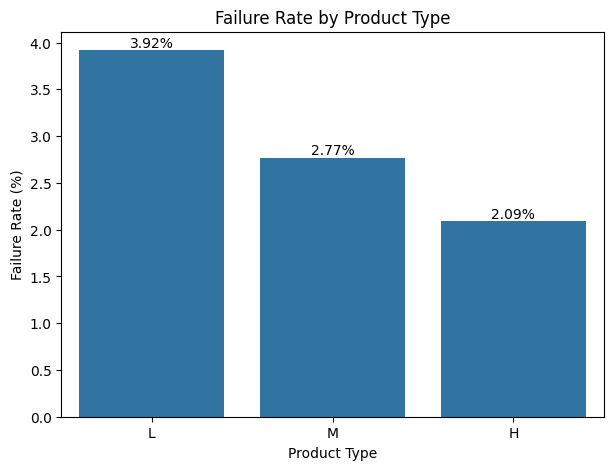

In [82]:
plt.figure(figsize=(7, 5))

ax = sns.barplot(
    data=type_failure_summary.reset_index(),
    x="product_type",
    y="failure_rate_percentage",
    order=["L", "M", "H"]
)

for container in ax.containers:
    ax.bar_label(container, fmt="%.2f%%")

plt.title("Failure Rate by Product Type")
plt.xlabel("Product Type")
plt.ylabel("Failure Rate (%)")
plt.show()

failure rate is the largest in the low product type

In [83]:
feature_labels = {
    "air_temperature": "Air Temperature [K]",
    "process_temperature": "Process Temperature [K]",
    "rotational_speed": "Rotational Speed [rpm]",
    "torque": "Torque [Nm]",
    "tool_wear": "Tool Wear [min]"
}

In [84]:
def plot_boxplot_by_failure(data, column, ylabel):
    plt.figure(figsize=(8, 5))

    sns.boxplot(
        data=data,
        x="failure_label",
        y=column,
        order=["No Failure", "Failure"]
    )

    plt.title(f"{ylabel} by Machine Condition")
    plt.xlabel("Machine Condition")
    plt.ylabel(ylabel)
    plt.show()

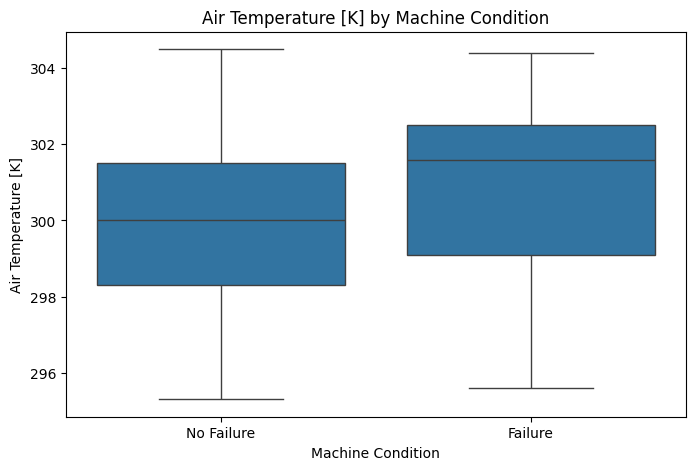

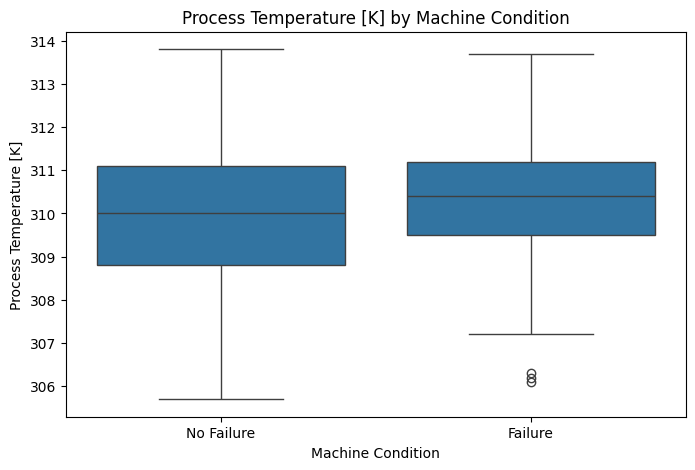

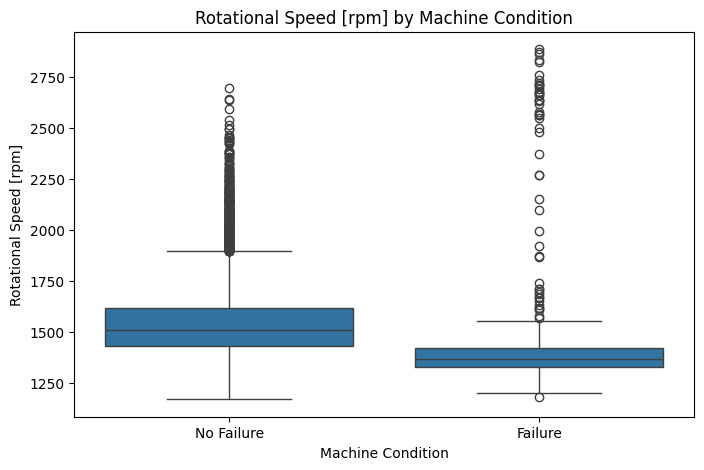

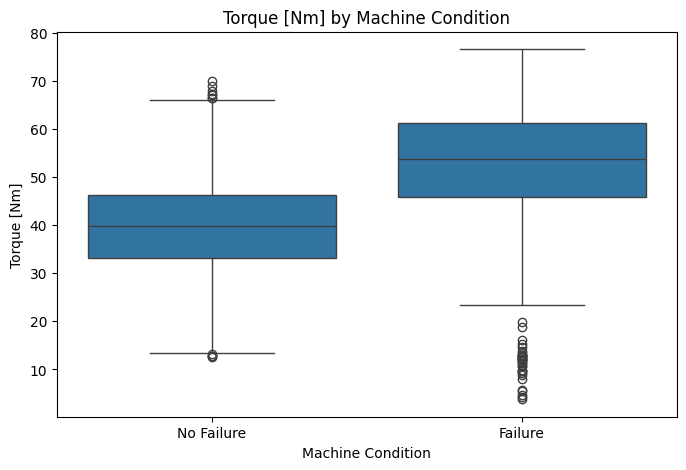

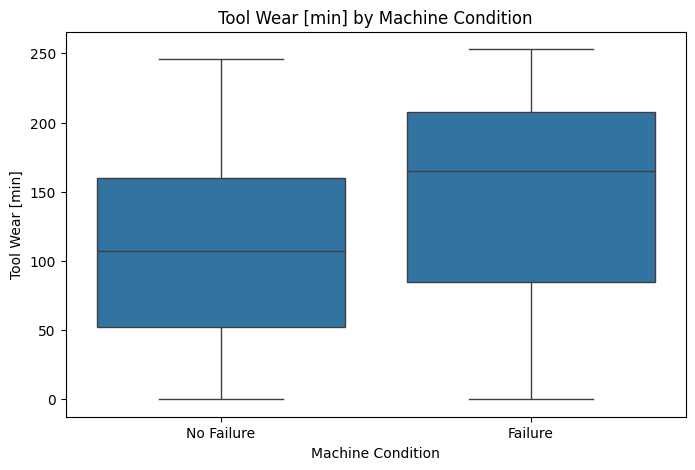

In [85]:
for feature, label in feature_labels.items():
    plot_boxplot_by_failure(
        df,
        feature,
        label
    )

some outliers are detected but not all of them will be removed



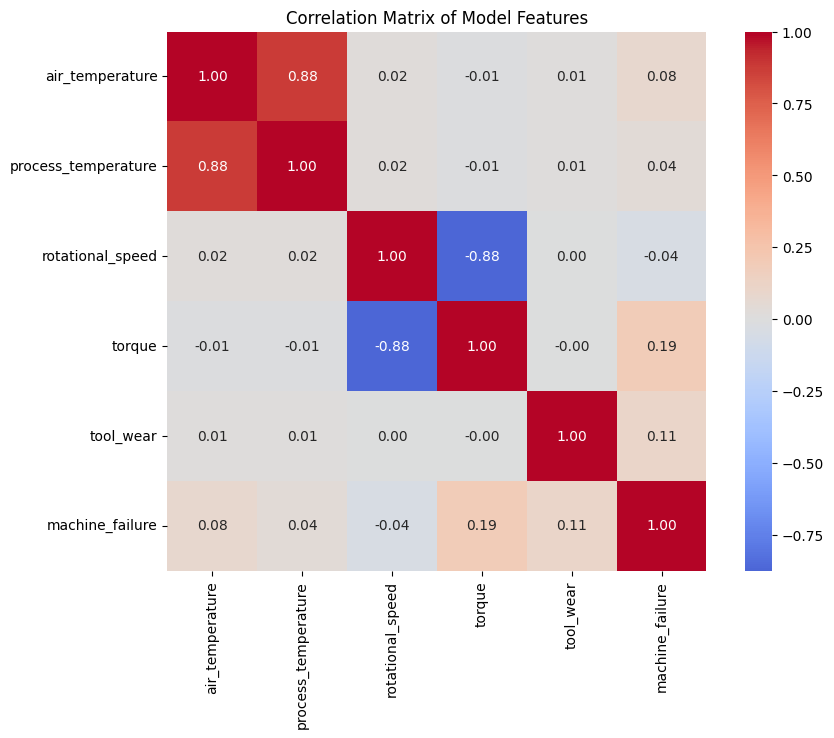

In [86]:
correlation_matrix = df[numerical_features + ['machine_failure']].corr()

plt.figure(figsize=(10, 7))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    square=True
)

plt.title("Correlation Matrix of Model Features")
plt.show()

* Air temperature and process temperatureare strongly positively correlated.
* Rotational speed and torque are negatively correlated.
* A weak linear correlation with failure does not mean that a feature is useless.
* Failure may depend on combinations of features rather than one feature alone.

In [87]:
failure_type_columns = [
    "twf",
    "hdf",
    "pwf",
    "osf",
    "rnf"
]

failure_type_counts = (
    df[failure_type_columns]
    .sum()
    .sort_values(ascending=False)
    .to_frame("Count")
)

failure_type_counts

,Count
hdf,115
osf,98
pwf,95
twf,46
rnf,19


These columns are useful for EDA but will be excluded from model inputs.

In [88]:
failure_names = {
    "twf": "Tool Wear Failure",
    "hdf": "Heat Dissipation Failure",
    "pwf": "Power Failure",
    "osf": "Overstrain Failure",
    "rnf": "Random Failure"
}

failure_type_plot = failure_type_counts.reset_index()
failure_type_plot["Failure Type"] = (
    failure_type_plot["index"].map(failure_names)
)

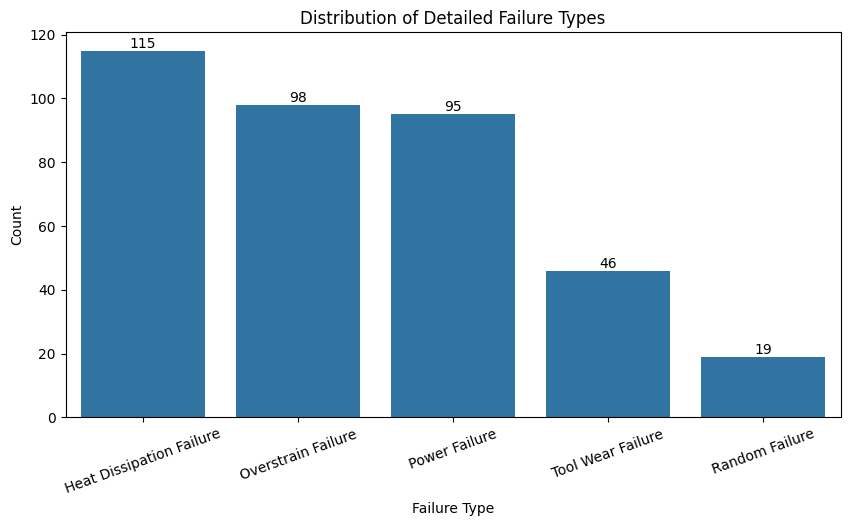

In [89]:
plt.figure(figsize=(10, 5))

ax = sns.barplot(
    data=failure_type_plot,
    x="Failure Type",
    y="Count"
)

for container in ax.containers:
    ax.bar_label(container)

plt.title("Distribution of Detailed Failure Types")
plt.xlabel("Failure Type")
plt.ylabel("Count")
plt.xticks(rotation=20)
plt.show()

the most vital reason of the failure of the machine is the hwf

In [90]:
df["number_of_failure_types"] = (
    df[failure_type_columns].sum(axis=1)
)

df["number_of_failure_types"].value_counts().sort_index()


number_of_failure_types
0    9652
1     324
2      23
3       1
Name: count, dtype: int64

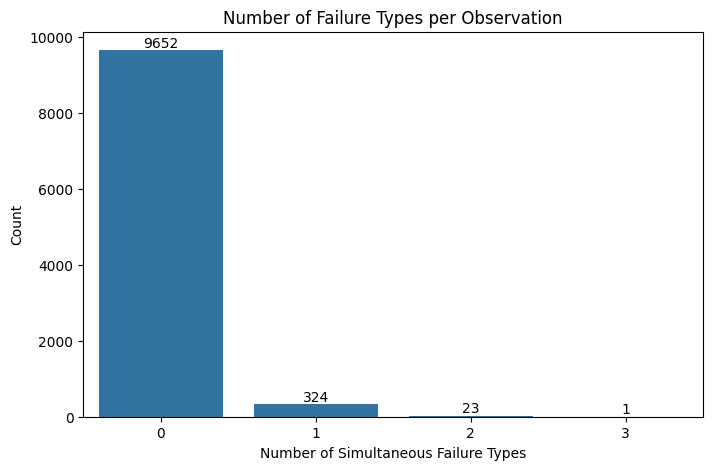

In [91]:
plt.figure(figsize=(8, 5))

ax = sns.countplot(
    data=df,
    x="number_of_failure_types"
)

for container in ax.containers:
    ax.bar_label(container)

plt.title("Number of Failure Types per Observation")
plt.xlabel("Number of Simultaneous Failure Types")
plt.ylabel("Count")
plt.show()

* Most machine operations were normal, confirming that the dataset is highly imbalanced.

* Most machine failures are caused by one identified failure mechanism rather than several simultaneous causes.


In [92]:
df["temperature_difference"] = (
    df["process_temperature"]
    - df["air_temperature"]
)

df["power_w"] = (
    df["torque"]
    * df["rotational_speed"]
    * 2
    * np.pi
    / 60
)

df["mechanical_strain"] = (
    df["tool_wear"]
    * df["torque"]
)

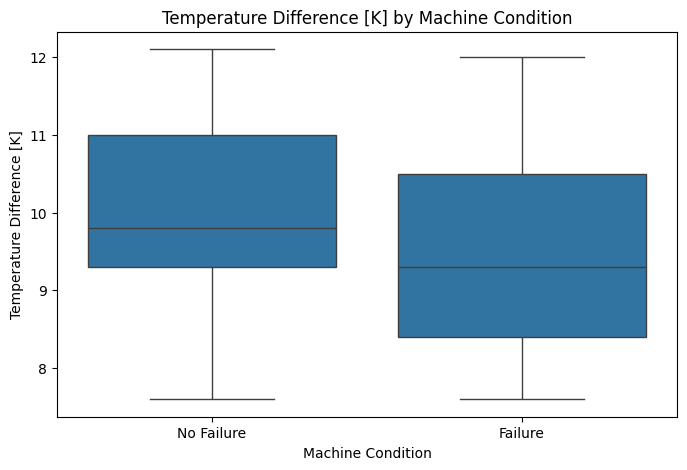

In [93]:
##########
plot_boxplot_by_failure(
    df,
    "temperature_difference",
    "Temperature Difference [K]"
)

#### **Insights: Temperature Difference**

*   **Higher Median for No Failure:** Machines operating normally (No Failure) tend to have a slightly higher median temperature difference compared to those with failures.
*   **Wider Distribution for No Failure:** The interquartile range (IQR) for 'No Failure' is wider, suggesting a more varied range of temperature differences during normal operation. This could indicate that the system can tolerate a broader range of temperature differences without failing.
*   **Outliers in Failure:** There are some outliers in the 'Failure' group with lower temperature differences, which might point to specific failure modes where the process temperature is not significantly higher than the air temperature, or even drops relative to air temperature, potentially indicating a system malfunction.
*   **Slightly Lower Median for Failure:** The median temperature difference for machines experiencing 'Failure' is slightly lower. This could suggest that a reduced temperature difference (i.e., process temperature being less elevated above air temperature) might be indicative of a problem, such as insufficient heating or an anomaly affecting the process's thermal regulation.

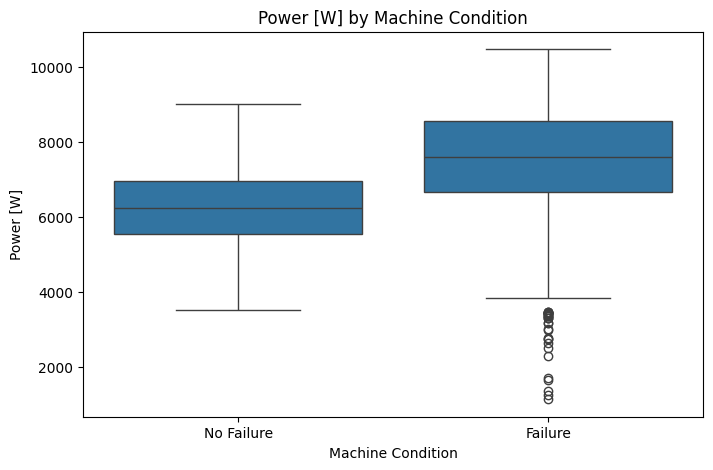

In [94]:
##########
plot_boxplot_by_failure(
    df,
    "power_w",
    "Power [W]"
)

#### **Insights: Power [W]**

*   **Higher Median for Failure:** Machines that experience failure show a significantly higher median power consumption compared to those operating normally. This suggests that failures are often associated with increased energy expenditure.
*   **Broader Range for Failure:** The 'Failure' box plot has a wider interquartile range (IQR) and more extreme outliers, indicating a greater variability in power consumption during failure events. This could be due to different failure modes requiring different levels of power or the system working harder to compensate before breaking down.
*   **Distinct Distributions:** The two distributions (No Failure vs. Failure) are quite distinct, with minimal overlap in their core ranges, making power a potentially strong indicator for machine failure. High power usage might be a critical precursor or a direct consequence of a machine malfunction.
*   **Upper Tail of No Failure:** The upper whisker of the 'No Failure' group extends into the lower range of the 'Failure' group, suggesting that some high power operations are normal, but exceeding a certain threshold is highly indicative of failure.

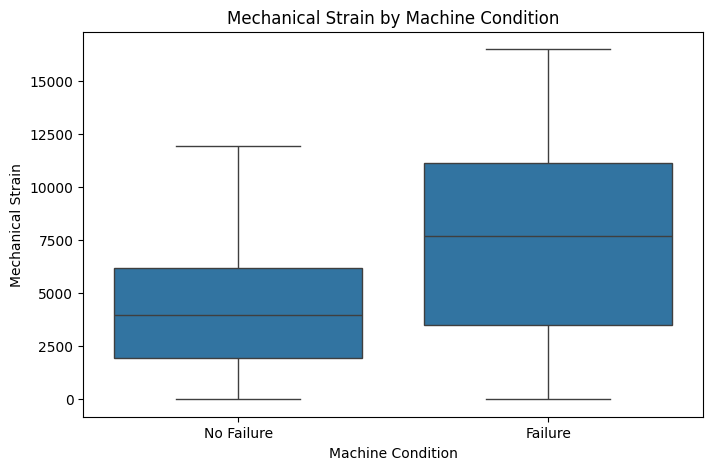

In [95]:
##########
plot_boxplot_by_failure(
    df,
    "mechanical_strain",
    "Mechanical Strain"
)

#### **Insights: Mechanical Strain**

*   **Significantly Higher Median for Failure:** The median mechanical strain for machines experiencing 'Failure' is substantially higher than for those with 'No Failure'. This clearly indicates that increased mechanical stress on the tool is a strong predictor or consequence of machine failure.
*   **Wider Spread in Failure:** The distribution of mechanical strain for 'Failure' is much broader, with a larger IQR and more high-value outliers. This suggests that various failure scenarios involve different magnitudes of strain, with some failures associated with extremely high strain levels.
*   **Minimal Overlap:** There is very little overlap between the typical ranges (IQR) of 'No Failure' and 'Failure' groups. This makes mechanical strain a highly discriminating feature for identifying potential machine failures.
*   **Zero Strain in No Failure:** A notable portion of 'No Failure' observations show very low or near-zero mechanical strain, which is expected during periods of light load or idle operation. In contrast, even the lowest values in the 'Failure' group are considerably higher than the median 'No Failure' strain.

In [96]:
engineered_features = [
    "temperature_difference",
    "power_w",
    "mechanical_strain"
]

df[engineered_features].describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
temperature_difference,10000.0,10.00,1.00,7.60,9.30,9.80,11.0,12.10
power_w,10000.0,6279.74,1067.42,1148.44,5561.18,6271.03,7003.0,10469.92
mechanical_strain,10000.0,4314.66,2826.57,0.00,1963.65,4012.95,6279.0,16497.00


In [97]:
df.groupby("machine_failure")[
    engineered_features
].median().round(2)

,temperature_difference,power_w,mechanical_strain
machine_failure,,,
0,9.8,6243.05,3952.8
1,9.3,7611.43,7681.8


In [98]:
failure_rows = df[df["machine_failure"] == 1]

normal_sample = df[
    df["machine_failure"] == 0
].sample(
    n=2000,
    random_state=42
)

plot_data = pd.concat(
    [normal_sample, failure_rows],
    ignore_index=True
)

plot_data["condition"] = plot_data["machine_failure"].map({
    0: "No Failure",
    1: "Failure"
})

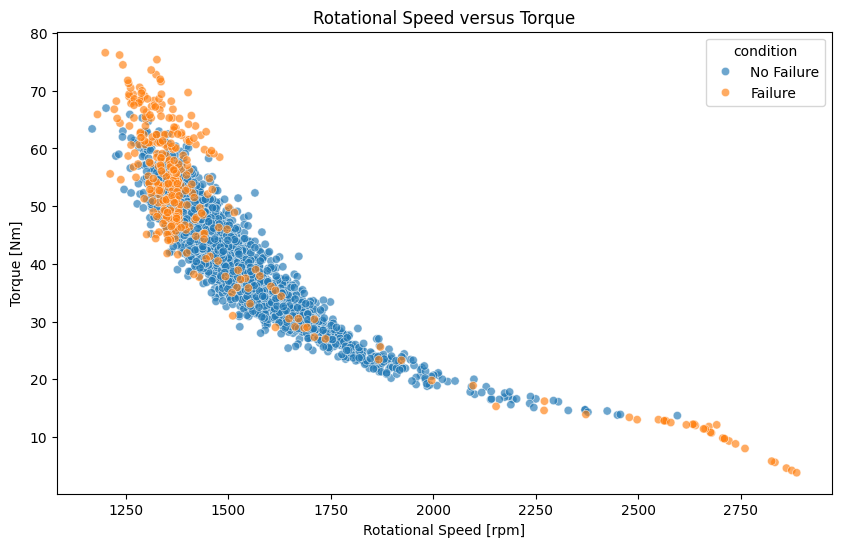

In [99]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=plot_data,
    x="rotational_speed",
    y="torque",
    hue="condition",
    alpha=0.65
)

plt.title("Rotational Speed versus Torque")
plt.xlabel("Rotational Speed [rpm]")
plt.ylabel("Torque [Nm]")
plt.show()

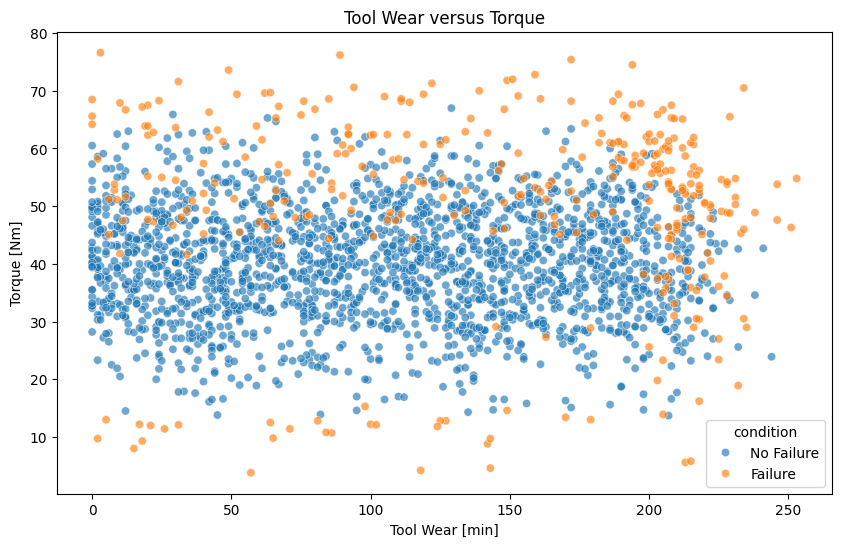

In [100]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=plot_data,
    x="tool_wear",
    y="torque",
    hue="condition",
    alpha=0.65
)

plt.title("Tool Wear versus Torque")
plt.xlabel("Tool Wear [min]")
plt.ylabel("Torque [Nm]")
plt.show()

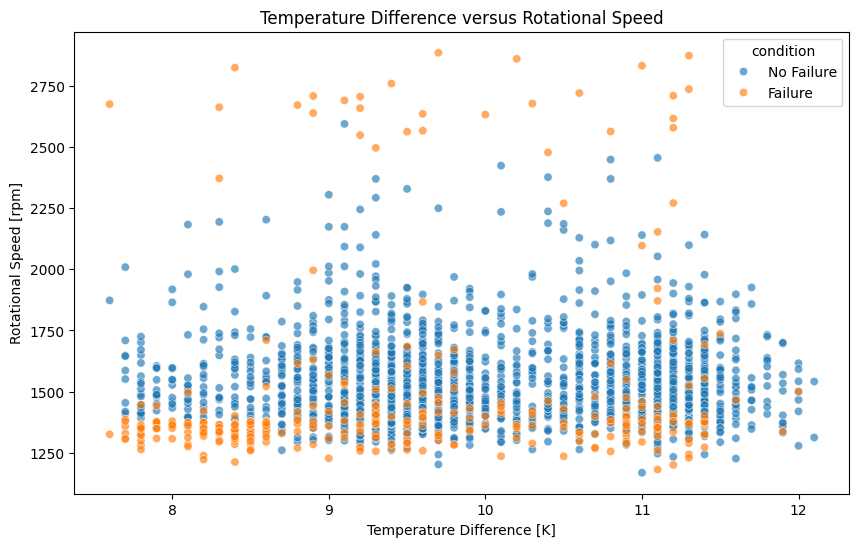

In [101]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=plot_data,
    x="temperature_difference",
    y="rotational_speed",
    hue="condition",
    alpha=0.65
)

plt.title("Temperature Difference versus Rotational Speed")
plt.xlabel("Temperature Difference [K]")
plt.ylabel("Rotational Speed [rpm]")
plt.show()

 insights for the three charts above:

 Failure observations appear more frequently in operating regions involving low rotational speed and high torque. High torque combined with greater tool wear also appears associated with failure. This suggests that feature interactions are more informative than individual measurements alone.

In [102]:
outlier_results = []

for feature in numerical_features:
    q1 = df[feature].quantile(0.25)
    q3 = df[feature].quantile(0.75)
    iqr = q3 - q1

    lower_limit = q1 - 1.5 * iqr
    upper_limit = q3 + 1.5 * iqr

    outlier_count = (
        (df[feature] < lower_limit)
        | (df[feature] > upper_limit)
    ).sum()

    outlier_results.append({
        "feature": feature,
        "lower_limit": round(lower_limit, 2),
        "upper_limit": round(upper_limit, 2),
        "outlier_count": outlier_count,
        "outlier_percentage": round(
            outlier_count / len(df) * 100,
            2
        )
    })

outlier_summary = pd.DataFrame(outlier_results)

outlier_summary

,feature,lower_limit,upper_limit,outlier_count,outlier_percentage
0,air_temperature,293.50,306.30,0,0.00
1,process_temperature,305.35,314.55,0,0.00
2,rotational_speed,1139.50,1895.50,418,4.18
3,torque,12.80,67.20,69,0.69
4,tool_wear,-110.50,325.50,0,0.00


* Extreme values will not be automatically removed because unusual torque, speed, or temperature measurements may represent genuine machine-failure conditions rather than data-entry errors.

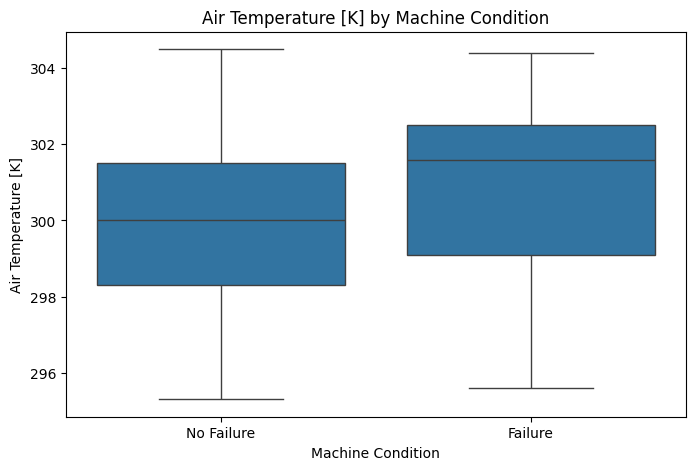

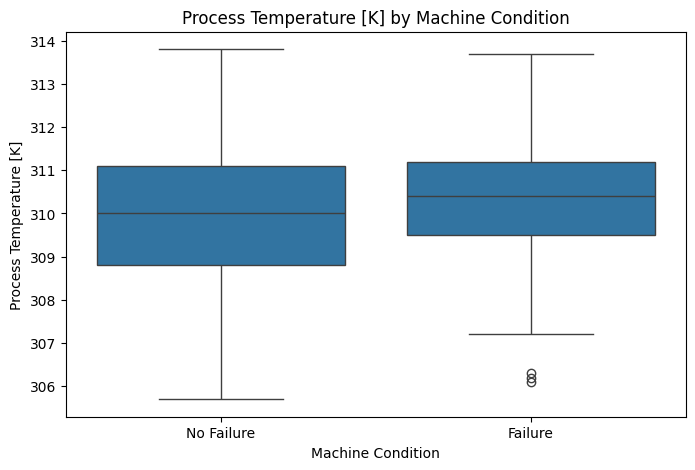

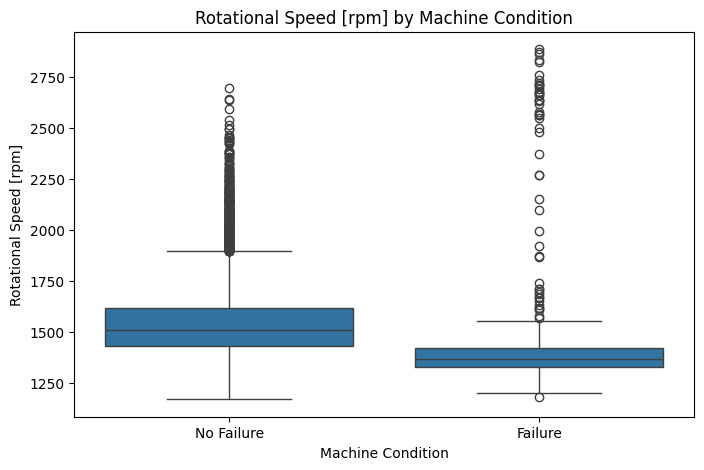

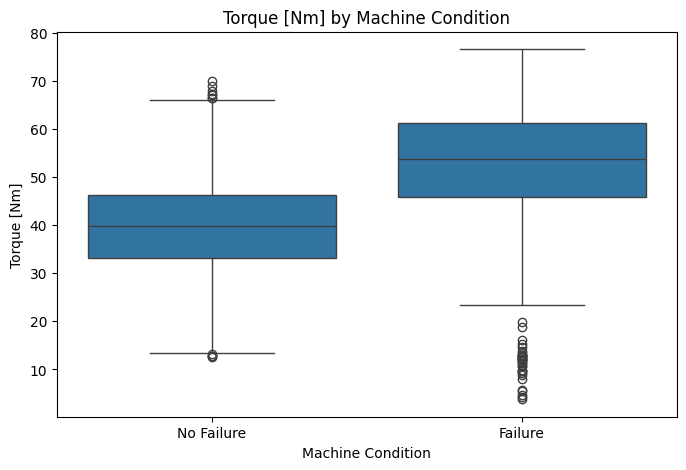

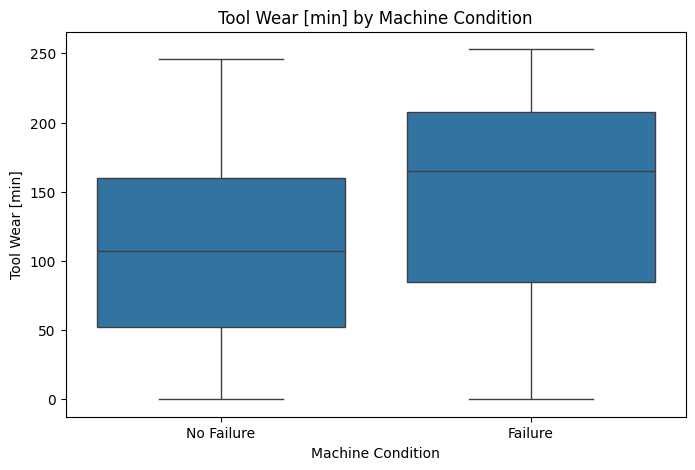

In [103]:
for feature, label in feature_labels.items():
    plot_boxplot_by_failure(
        df,
        feature,
        label
    )

* ensuring that not all outliers are removed

# EDA summary

In [104]:
eda_summary = pd.DataFrame({
    "item": [
        "Number of observations",
        "Number of original columns",
        "Missing values",
        "Duplicated rows",
        "Normal observations",
        "Failure observations",
        "Failure percentage",
        "Normal-to-failure ratio"
    ],
    "result": [
        len(df),
        14,
        df.isnull().sum().sum(),
        df.duplicated().sum(),
        (df["machine_failure"] == 0).sum(),
        (df["machine_failure"] == 1).sum(),
        round(df["machine_failure"].mean() * 100, 2),
        round(
            (df["machine_failure"] == 0).sum()
            / (df["machine_failure"] == 1).sum(),
            2
        )
    ]
})

eda_summary

,item,result
0,Number of observations,10000.00
1,Number of original columns,14.00
2,Missing values,0.00
3,Duplicated rows,0.00
4,Normal observations,9661.00
5,Failure observations,339.00
6,Failure percentage,3.39
7,Normal-to-failure ratio,28.50


* The dataset is complete and contains no missing values. However, it is strongly imbalanced, with failures representing only 3.39% of observations. Failed operations generally show lower rotational speed, higher torque, and greater tool wear. Strong correlations exist between air and process temperatures and between rotational speed and torque. Interaction analysis suggests that combinations of operational measurements are more useful than individual features. Identifier columns and detailed failure labels will be excluded from model inputs.

In [105]:
df.head(5)

,udi,product_id,product_type,air_temperature,process_temperature,rotational_speed,torque,tool_wear,machine_failure,twf,hdf,pwf,osf,rnf,failure_label,number_of_failure_types,temperature_difference,power_w,mechanical_strain
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0,No Failure,0,10.5,6951.590560,0.0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0,No Failure,0,10.5,6826.722724,138.9
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0,No Failure,0,10.4,7749.387543,247.0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0,No Failure,0,10.4,5927.504659,276.5
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0,No Failure,0,10.5,5897.816608,360.0


In [106]:
df['failure_label'].value_counts()

failure_label
No Failure    9661
Failure        339
Name: count, dtype: int64

#Data Cleaning and Preprocessing


In [107]:
df = df.drop(columns=["udi", "product_id"])

assert df.isnull().sum().sum() == 0, "Unexpected missing values"
df = df.drop_duplicates()

#The five failure-mode columns (TWF/HDF/PWF/OSF/RNF) stay in the dataframe but aren't used as input features for the
#failure-prediction model due to leakage — instead they're used as the target for a separate root-cause model.
cause_cols = ["twf", "hdf", "pwf", "osf", "rnf"]
target_col = "machine_failure"

#FEATURE ENGINEERING


In [108]:
df["Temp_diff"] = df["process_temperature"] - df["air_temperature"]
df["Power_W"] = df["torque"] * (df["rotational_speed"] * 2 * np.pi / 60)
df["Strain"] = df["torque"] * df["tool_wear"]
df["Speed_Torque_ratio"] = df["rotational_speed"] / (df["torque"] + 1e-6)

numeric_features = [
    "air_temperature", "process_temperature", "rotational_speed",
    "torque", "tool_wear", "Temp_diff", "Power_W",
    "Strain", "Speed_Torque_ratio"
]
categorical_features = ["product_type"]
feature_cols = numeric_features + categorical_features

preprocessor = ColumnTransformer(transformers=[
    ("num", StandardScaler(), numeric_features),
    ("cat", OrdinalEncoder(categories=[["L", "M", "H"]]), categorical_features),
])


# STAGE 1: Predict Machine failure (Yes/No)

In [109]:
X = df[feature_cols]
y = df[target_col]

RANDOM_STATE = 42

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=RANDOM_STATE
)

print("=" * 60)
print("Original Dataset")
print("=" * 60)
print(f"Training samples : {len(X_train)}")
print(f"Testing samples  : {len(X_test)}")
print(f"Train class balance before SMOTE:\n{y_train.value_counts()}")
print()

# ==========================================================
# Voting Classifier
# ==========================================================

voting_model = VotingClassifier(
    estimators=[
        ("lr", LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)),
        ("rf", RandomForestClassifier(
            n_estimators=300,
            random_state=RANDOM_STATE,
            n_jobs=-1
        )),
        ("svm", SVC(
            kernel="rbf",
            probability=True,
            random_state=RANDOM_STATE
        ))
    ],
    voting="soft"
)

# ==========================================================
# Models
# ==========================================================

models = {

    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        random_state=RANDOM_STATE
    ),

    "KNN": KNeighborsClassifier(
        n_neighbors=5
    ),

    "Decision Tree": DecisionTreeClassifier(
        random_state=RANDOM_STATE
    ),

    "Bagging": BaggingClassifier(
        estimator=DecisionTreeClassifier(random_state=RANDOM_STATE),
        n_estimators=200,
        random_state=RANDOM_STATE,
        n_jobs=-1
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        random_state=RANDOM_STATE,
        n_jobs=-1
    ),

    "SVM": SVC(
        kernel="rbf",
        probability=True,
        random_state=RANDOM_STATE
    ),

    "Voting": voting_model,

    "Naive Bayes": GaussianNB()
}

results = []
fitted_pipelines = {}

# ==========================================================
# Training & Evaluation
# ==========================================================

for name, model in models.items():

    pipe = ImbPipeline(steps=[
        ("preprocessor", preprocessor),
        ("smote", SMOTE(random_state=RANDOM_STATE)),
        ("classifier", model)
    ])

    # Fit pipeline
    pipe.fit(X_train, y_train)

    fitted_pipelines[name] = pipe

    # ======================================================
    # Show SMOTE effect
    # ======================================================

    X_train_processed = pipe.named_steps["preprocessor"].fit_transform(X_train)

    X_smote, y_smote = pipe.named_steps["smote"].fit_resample(
        X_train_processed,
        y_train
    )

    print(f"\n{'='*65}")
    print(name)
    print("="*65)

    print(f"Training size before SMOTE : {len(X_train)}")
    print(f"Training size after SMOTE  : {len(X_smote)}")
    print(f"Testing size               : {len(X_test)}")

    print("\nClass Distribution After SMOTE:")
    print(pd.Series(y_smote).value_counts())

    # ======================================================
    # Prediction
    # ======================================================

    y_pred = pipe.predict(X_test)
    y_proba = pipe.predict_proba(X_test)[:, 1]

    # ======================================================
    # Metrics
    # ======================================================

    results.append({

        "Model": name,

        "Accuracy": accuracy_score(y_test, y_pred),

        "Precision": precision_score(y_test, y_pred),

        "Recall": recall_score(y_test, y_pred),

        "F1": f1_score(y_test, y_pred),

        "ROC-AUC": roc_auc_score(y_test, y_proba),

        "PR-AUC": average_precision_score(y_test, y_proba)

    })

    print("\nConfusion Matrix:")
    print(confusion_matrix(y_test, y_pred))

    print("\nClassification Report:")
    print(classification_report(y_test, y_pred, digits=3))

    print(f"ROC-AUC : {roc_auc_score(y_test, y_proba):.4f}")
    print(f"PR-AUC  : {average_precision_score(y_test, y_proba):.4f}")

# ==========================================================
# Final Comparison
# ==========================================================

results_df = pd.DataFrame(results).sort_values(
    by="F1",
    ascending=False
)

print("\n")
print("="*70)
print("FINAL MODEL COMPARISON")
print("="*70)

print(results_df.to_string(index=False))

results_df.to_csv(
    "D:/NTI Machine Learning for Data Analysis/stage1_model_comparison.csv",
    index=False
)

best_model_name = results_df.iloc[0]["Model"]
best_pipeline = fitted_pipelines[best_model_name]

print(f"\nBest Stage-1 Model: {best_model_name}")

Original Dataset
Training samples : 8000
Testing samples  : 2000
Train class balance before SMOTE:
machine_failure
0    7729
1     271
Name: count, dtype: int64


Logistic Regression
Training size before SMOTE : 8000
Training size after SMOTE  : 15458
Testing size               : 2000

Class Distribution After SMOTE:
machine_failure
0    7729
1    7729
Name: count, dtype: int64

Confusion Matrix:
[[1643  289]
 [   7   61]]

Classification Report:
              precision    recall  f1-score   support

           0      0.996     0.850     0.917      1932
           1      0.174     0.897     0.292        68

    accuracy                          0.852      2000
   macro avg      0.585     0.874     0.605      2000
weighted avg      0.968     0.852     0.896      2000

ROC-AUC : 0.9411
PR-AUC  : 0.4308

KNN
Training size before SMOTE : 8000
Training size after SMOTE  : 15458
Testing size               : 2000

Class Distribution After SMOTE:
machine_failure
0    7729
1    7729
Name: count

Although SVM achieved a higher recall, its F1-score was much lower because it generated many false alarms (false positives). On the other hand, Random Forest achieved a better balance between precision and recall, making it the more suitable model overall.

In [110]:
set_config(display="diagram")
display(best_pipeline)

,steps,"[('preprocessor', ...), ('smote', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The

In [111]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


# Apply Preprocessing (Scaling and One-Hot Encoding)


X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

# 2) Apply SMOTE on Training Data Only

smote = SMOTE(random_state=42)

X_train_sm, y_train_sm = smote.fit_resample(
    X_train_processed,
    y_train
)

print("Before SMOTE:")
print(y_train.value_counts())

print("\nAfter SMOTE:")
print(y_train_sm.value_counts())


# 3) Train Random Forest


from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

rf.fit(
    X_train_sm,
    y_train_sm
)


# 4) Evaluation with Default Threshold 0.5


from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    roc_auc_score
)

y_pred = rf.predict(X_test_processed)

print("\n===== Threshold = 0.5 =====")

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print(
    "ROC-AUC:",
    roc_auc_score(
        y_test,
        rf.predict_proba(X_test_processed)[:,1]
    )
)



# 5) Change Decision Threshold

y_prob = rf.predict_proba(X_test_processed)[:,1]


thresholds = [0.5, 0.4, 0.3, 0.2]


for threshold in thresholds:

    y_pred_threshold = (
        y_prob >= threshold
    ).astype(int)

    print("\n======================")
    print("Threshold:", threshold)

    print(
        confusion_matrix(
            y_test,
            y_pred_threshold
        )
    )

    print(
        classification_report(
            y_test,
            y_pred_threshold
        )
    )

Before SMOTE:
machine_failure
0    7729
1     271
Name: count, dtype: int64

After SMOTE:
machine_failure
0    7729
1    7729
Name: count, dtype: int64

===== Threshold = 0.5 =====
Confusion Matrix:
[[1903   29]
 [  11   57]]

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.98      0.99      1932
           1       0.66      0.84      0.74        68

    accuracy                           0.98      2000
   macro avg       0.83      0.91      0.86      2000
weighted avg       0.98      0.98      0.98      2000

ROC-AUC: 0.981944951893801

Threshold: 0.5
[[1903   29]
 [  11   57]]
              precision    recall  f1-score   support

           0       0.99      0.98      0.99      1932
           1       0.66      0.84      0.74        68

    accuracy                           0.98      2000
   macro avg       0.83      0.91      0.86      2000
weighted avg       0.98      0.98      0.98      2000


Threshold: 0.4
[[1880   5

Random Forest + SMOTE + Optimized Decision Threshold (0.4)

because it achieves a high Recall while reducing false alarms..

# STAGE 2: Root-Cause identification (multi-label)
# Trained ONLY on rows where a failure actually occurred, using the
# same sensor/engineered features. Target = the 5 cause columns.


In [112]:

cause_columns = ["twf", "hdf", "pwf", "osf", "rnf"]

# Train only on failed machines
failure_df = df[df["machine_failure"] == 1].copy()

X_failure = failure_df[feature_cols]
Y_failure = failure_df[cause_columns]

print("Failure samples:", len(failure_df))
print(Y_failure.sum())

# Train/Test Split
X_train2, X_test2, y_train2, y_test2 = train_test_split(
    X_failure,
    Y_failure,
    test_size=0.2,
    random_state=RANDOM_STATE
)

# Use the same preprocessor from Stage 1
X_train2 = preprocessor.fit_transform(X_train2)
X_test2 = preprocessor.transform(X_test2)

from sklearn.multiclass import OneVsRestClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

cause_model = OneVsRestClassifier(

    RandomForestClassifier(
        n_estimators=300,
        random_state=RANDOM_STATE,
        class_weight="balanced"
    )

)

cause_model.fit(X_train2, y_train2)

pred = cause_model.predict(X_test2)

print(
    classification_report(
        y_test2,
        pred,
        target_names=[
            "Tool Wear",
            "Heat Dissipation",
            "Power Failure",
            "Overstrain",
            "Random Failure"
        ]
    )
)

Failure samples: 339
twf     46
hdf    115
pwf     95
osf     98
rnf      1
dtype: int64
                  precision    recall  f1-score   support

       Tool Wear       1.00      0.73      0.85        15
Heat Dissipation       0.95      1.00      0.98        21
   Power Failure       0.92      1.00      0.96        12
      Overstrain       1.00      1.00      1.00        23
  Random Failure       0.00      0.00      0.00         0

       micro avg       0.97      0.94      0.96        71
       macro avg       0.78      0.75      0.76        71
    weighted avg       0.97      0.94      0.95        71
     samples avg       0.90      0.90      0.90        71



c:\Users\DELL\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\DELL\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\DELL\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in labels with no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average

In [113]:
cause_names = {
    "twf":"Tool Wear Failure",
    "hdf":"Heat Dissipation Failure",
    "pwf":"Power Failure",
    "osf":"Overstrain Failure",
    "rnf":"Random Failure"
}

def predict_root_cause(user_input):

    sample = pd.DataFrame([user_input])

    sample = preprocessor.transform(sample)

    prediction = cause_model.predict(sample)[0]

    causes = []

    for i,col in enumerate(cause_columns):

        if prediction[i] == 1:

            causes.append(cause_names[col])

    if len(causes)==0:
        causes.append("Unknown Failure")

    return causes

# END-TO-END DEMO: predict failure, then (if failed) predict cause


In [114]:


user_input = {

    "product_type":"L",

    "air_temperature":300,

    "process_temperature":311,

    "rotational_speed":1350,

    "torque":58,

    "tool_wear":220
}
user_input["Temp_diff"] = (
    user_input["process_temperature"]
    - user_input["air_temperature"]
)

user_input["Power_W"] = (
    user_input["torque"]
    *
    (
        user_input["rotational_speed"]
        *2*np.pi/60
    )
)

user_input["Strain"] = (
    user_input["torque"]
    *
    user_input["tool_wear"]
)

user_input["Speed_Torque_ratio"] = (
    user_input["rotational_speed"]
    /
    (user_input["torque"]+1e-6)
)

sample = pd.DataFrame([user_input])

failure = best_pipeline.predict(sample)[0]

prob = best_pipeline.predict_proba(sample)[0][1]

print("="*50)

print(f"Failure Probability : {prob:.2%}")

print("="*50)

if failure == 1:

    print("Machine Failure Detected\n")

    print("Likely Root Cause(s):")

    causes = predict_root_cause(user_input)

    for c in causes:

        print("•",c)

else:

    print("Machine is Healthy")

Failure Probability : 0.33%
Machine is Healthy


# Save Modeling

In [115]:
import joblib

# Stage 1
joblib.dump(best_pipeline, "machine_failure_model.pkl")

# Stage 2
joblib.dump(cause_model, "failure_cause_model.pkl")

# Preprocessor
joblib.dump(preprocessor, "preprocessor.pkl")

print("All models saved successfully.")

All models saved successfully.


In [116]:
recommendations = {

    "Tool Wear Failure":[

        "Replace the worn tool.",
        "Inspect cutting edges.",
        "Schedule preventive maintenance."

    ],

    "Heat Dissipation Failure":[

        "Check cooling system.",
        "Inspect coolant flow.",
        "Reduce machine temperature."

    ],

    "Power Failure":[

        "Inspect power supply.",
        "Check motor efficiency.",
        "Monitor electrical components."

    ],

    "Overstrain Failure":[

        "Reduce machine load.",
        "Check spindle alignment.",
        "Inspect mechanical stress."

    ],

    "Random Failure":[

        "Perform full inspection.",
        "Check sensors.",
        "Monitor machine closely."

    ]

}